In [98]:
import itertools

import sympy as sy
import numpy as np

In [99]:
import fitz

Tamanho dos vetores

In [100]:
from utils import plot_pdf

In [101]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This example will not work for different vector sizes.

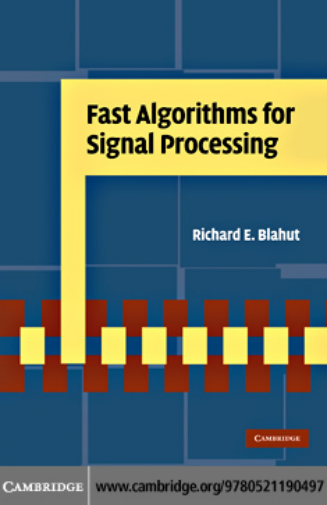

In [102]:
plot_pdf(doc[0], dpi=100)

In [103]:
d_num = 3
g_num = 3

Vetor de exemplo

In [104]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))

Grau do polinômio

In [105]:
d_degree = d_num - 1
g_degree = g_num - 1

In [106]:
x = sy.symbols("x")

In [107]:
# sy.factor(x**4-1)

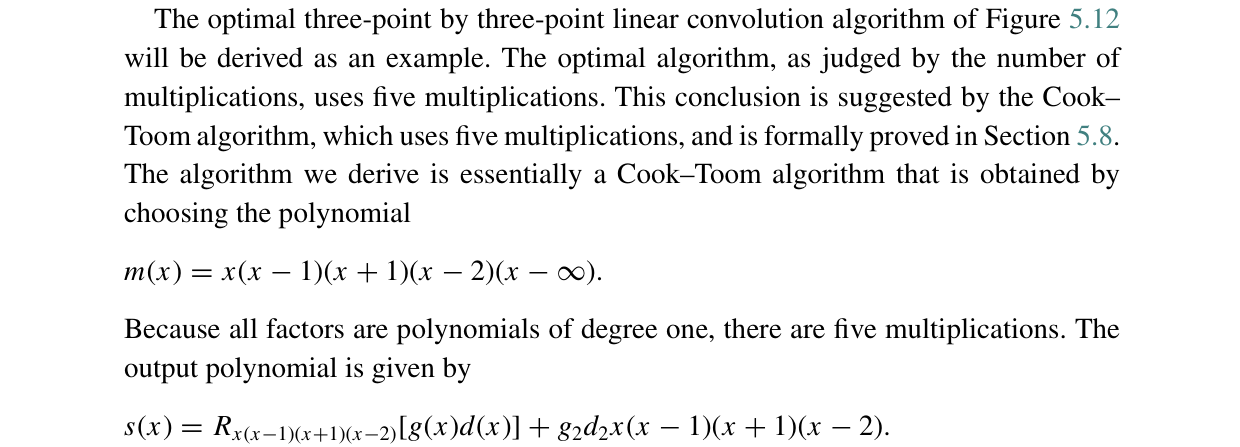

In [152]:
plot_pdf(doc[181], [.435, .67])

Total of residues

In [110]:
d_degree + g_degree

4

In [111]:
# mk0 = [x + i*r for r in range(1, d_degree + g_degree - 1) for i in [-1, 1]]
# mk = sy.Matrix(([x] + mk0)[:d_degree + g_degree])

In [112]:
mk = sy.Matrix([x, x - 1, x + 1, x - 2])
mk

Matrix([
[    x],
[x - 1],
[x + 1],
[x - 2]])

In [113]:
di = sy.Matrix(sy.symbols(" ".join(f"d{i}"for i in range(d_num))))
di

Matrix([
[d0],
[d1],
[d2]])

In [114]:
gi = sy.Matrix(sy.symbols(" ".join(f"g{i}"for i in range(g_num))))
gi

Matrix([
[g0],
[g1],
[g2]])

In [115]:
dx = sum([i*x**e for e, i in enumerate(di)])
dx

d0 + d1*x + d2*x**2

In [116]:
gx = sum([i*x**e for e, i in enumerate(gi)])
gx

g0 + g1*x + g2*x**2

In [117]:
sx = gx*dx
sx

(d0 + d1*x + d2*x**2)*(g0 + g1*x + g2*x**2)

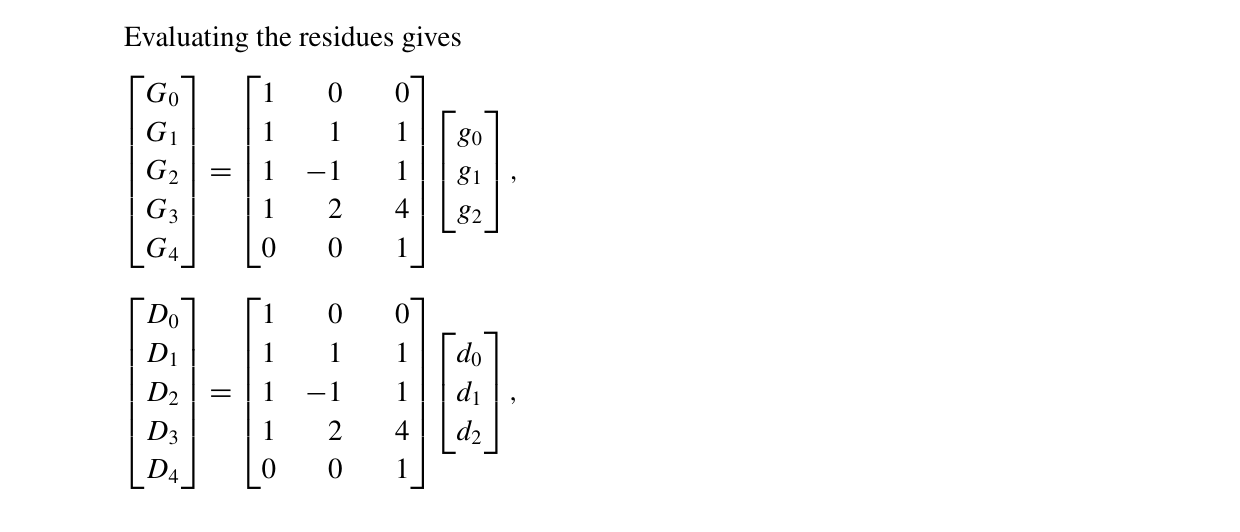

In [154]:
plot_pdf(doc[181], [.67, .95])

In [118]:
gk_ = [sy.rem(gx, q, domain ='ZZ') for q in mk]
gk = sy.Matrix(gk_ + [gx.args[-1].args[0]])
gk

Matrix([
[              g0],
[    g0 + g1 + g2],
[    g0 - g1 + g2],
[g0 + 2*g1 + 4*g2],
[              g2]])

In [119]:
dk_ = [sy.rem(dx, q, domain ='ZZ') for q in mk]
dk = sy.Matrix(dk_ + [dx.args[-1].args[0]])
dk

Matrix([
[              d0],
[    d0 + d1 + d2],
[    d0 - d1 + d2],
[d0 + 2*d1 + 4*d2],
[              d2]])

In [125]:
a_mtx = sy.Matrix([[d.coeff(c, 1) for c in di] for d in dk])
a_mtx

Matrix([
[1,  0, 0],
[1,  1, 1],
[1, -1, 1],
[1,  2, 4],
[0,  0, 1]])

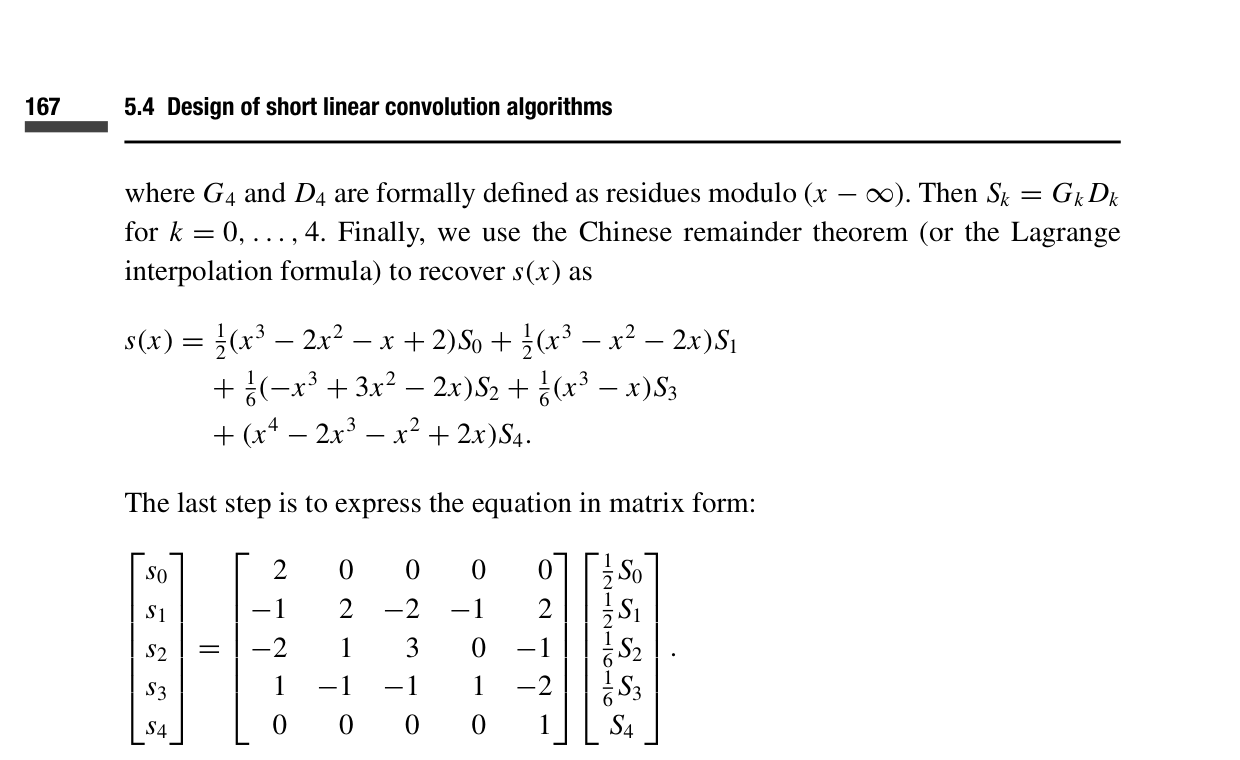

In [160]:
plot_pdf(doc[182], [.0, .4])

In [120]:
mmk_ = [sy.expand(np.prod(d)) for d in itertools.combinations(reversed(mk), len(mk)-1)]
mmk = sy.Matrix(mmk_ + [sy.expand(np.prod(mk))])
mmk

Matrix([
[     x**3 - 2*x**2 - x + 2],
[         x**3 - x**2 - 2*x],
[       x**3 - 3*x**2 + 2*x],
[                  x**3 - x],
[x**4 - 2*x**3 - x**2 + 2*x]])

Pegando quociente e resto, agora tem q colocar no formato nm+NM=1

In [121]:
mx_div = [sy.div(dv, ds, domain ='ZZ') for dv, ds in zip(mmk, mk)]
mx_div

[(x**2 - 2*x - 1, 2),
 (x**2 - 2, -2),
 (x**2 - 4*x + 6, -6),
 (x**2 + 2*x + 3, 6)]

Multiplicar o resto pela matriz G depois
o sinal negativo vai pra matriz G e não pra C

In [122]:
nnk = sy.Matrix([1/z[1] for z in mx_div])
nnk

Matrix([
[ 1/2],
[-1/2],
[-1/6],
[ 1/6]])

In [123]:
nk = sy.Matrix([q[0]*r*(-1) for q, r in zip(mx_div, nnk)])
nk

Matrix([
[  -x**2/2 + x + 1/2],
[         x**2/2 - 1],
[ x**2/6 - 2*x/3 + 1],
[-x**2/6 - x/3 - 1/2]])

In [129]:
c_mtx = sy.Matrix([[d.coeff(x, c) for d in mmk] for c in range(len(np.prod(mk).as_poly().all_coeffs()))])
c_mtx

Matrix([
[ 2,  0,  0,  0,  0],
[-1, -2,  2, -1,  2],
[-2, -1, -3,  0, -1],
[ 1,  1,  1,  1, -2],
[ 0,  0,  0,  0,  1]])

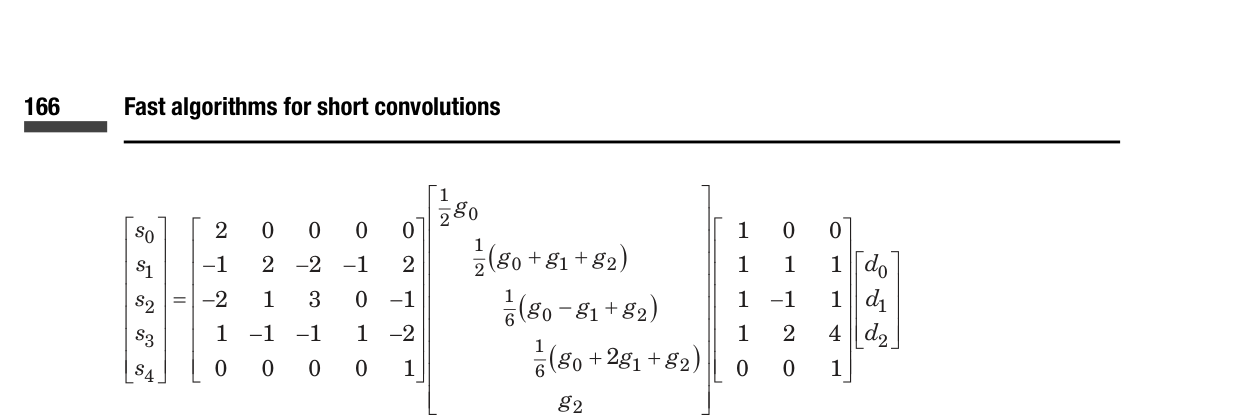

In [166]:
plot_pdf(doc[181], [0, .22])

In [126]:
bg_mtx = sy.diag(*([g*r for g, r in zip(gk.flat(), nnk.flat()+[1])]))
bg_mtx

Matrix([
[g0/2,                   0,                   0,                    0,  0],
[   0, -g0/2 - g1/2 - g2/2,                   0,                    0,  0],
[   0,                   0, -g0/6 + g1/6 - g2/6,                    0,  0],
[   0,                   0,                   0, g0/6 + g1/3 + 2*g2/3,  0],
[   0,                   0,                   0,                    0, g2]])

In [131]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di))
s

Matrix([
[ 2,  0,  0,  0,  0],
[-1, -2,  2, -1,  2],
[-2, -1, -3,  0, -1],
[ 1,  1,  1,  1, -2],
[ 0,  0,  0,  0,  1]])*Matrix([
[g0/2,                   0,                   0,                    0,  0],
[   0, -g0/2 - g1/2 - g2/2,                   0,                    0,  0],
[   0,                   0, -g0/6 + g1/6 - g2/6,                    0,  0],
[   0,                   0,                   0, g0/6 + g1/3 + 2*g2/3,  0],
[   0,                   0,                   0,                    0, g2]])*Matrix([
[1,  0, 0],
[1,  1, 1],
[1, -1, 1],
[1,  2, 4],
[0,  0, 1]])*Matrix([
[d0],
[d1],
[d2]])

In [132]:
subs = {k: v for k, v in zip(di.flat()+gi.flat(), d_values + g_values)}
subs

{d0: 1, d1: 2, d2: 3, g0: 1, g1: 2, g2: 3}

In [133]:
si = s.subs(subs)
si

Matrix([
[ 2,  0,  0,  0,  0],
[-1, -2,  2, -1,  2],
[-2, -1, -3,  0, -1],
[ 1,  1,  1,  1, -2],
[ 0,  0,  0,  0,  1]])*Matrix([
[1/2,  0,    0,    0, 0],
[  0, -3,    0,    0, 0],
[  0,  0, -1/3,    0, 0],
[  0,  0,    0, 17/6, 0],
[  0,  0,    0,    0, 3]])*Matrix([
[1,  0, 0],
[1,  1, 1],
[1, -1, 1],
[1,  2, 4],
[0,  0, 1]])*Matrix([
[1],
[2],
[3]])

In [134]:
sy.expand(sx)

d0*g0 + d0*g1*x + d0*g2*x**2 + d1*g0*x + d1*g1*x**2 + d1*g2*x**3 + d2*g0*x**2 + d2*g1*x**3 + d2*g2*x**4

Let's compare the output polynomial matrix from direct and winograd method

In [135]:
sy.Matrix(np.convolve(np.array(di).reshape(-1), np.array(gi).reshape(-1)))

Matrix([
[                d0*g0],
[        d0*g1 + d1*g0],
[d0*g2 + d1*g1 + d2*g0],
[        d1*g2 + d2*g1],
[                d2*g2]])

In [136]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(di), evaluate=True)
se

Matrix([
[                d0*g0],
[        d0*g1 + d1*g0],
[d0*g2 + d1*g1 + d2*g0],
[        d1*g2 + d2*g1],
[                d2*g2]])

Comparing numerical outputs from direct and winograd method

In [137]:
sy.Matrix(np.convolve(d_values, g_values))

Matrix([
[ 1],
[ 4],
[10],
[12],
[ 9]])

In [138]:
se.subs(subs)

Matrix([
[ 1],
[ 4],
[10],
[12],
[ 9]])